In [ ]:
# Qwen Object Eraser Inference
#
# - Base models: /mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen
# - Trained checkpoint: latest under shared train output
# - Inference sample: one record from validation metadata (val.jsonl)

In [1]:
from pathlib import Path
import json
import glob

import torch
from PIL import Image
from IPython.display import display

from diffsynth import load_state_dict
from diffsynth.pipelines.qwen_image import QwenImagePipeline, ModelConfig

SHARED_MODEL_ROOT = Path("/mnt/lica-data-2/for_jjseol/diffsynth_models")
QWEN_ROOT = SHARED_MODEL_ROOT / "Qwen"

DATASET_ROOT = Path("/home/ubuntu/for_jjseol/qwen_eraser_dataset")
VAL_JSONL_PATH = DATASET_ROOT / "val.jsonl"
VAL_SAMPLE_INDEX = 0

TRAIN_OUTPUT_ROOT = SHARED_MODEL_ROOT / "train/Qwen-Image-Edit-2511_full_layered_vae_object_eraser"
PREFER_LATEST_TRAINED_CHECKPOINT = True
MANUAL_CHECKPOINT_PATH = TRAIN_OUTPUT_ROOT / "step-30000.safetensors"

NEGATIVE_PROMPT = ""
NUM_INFERENCE_STEPS = 40
CFG_SCALE = 4.0
SEED = 123
CUDA_DEVICE_INDEX = 1
EDIT_IMAGE_AUTO_RESIZE = True
ZERO_COND_T = True

if not VAL_JSONL_PATH.exists():
    raise FileNotFoundError(f"Validation jsonl not found: {VAL_JSONL_PATH}")

with open(VAL_JSONL_PATH, "r", encoding="utf-8") as f:
    val_records = [json.loads(line) for line in f if line.strip()]

if not val_records:
    raise ValueError(f"No validation records found: {VAL_JSONL_PATH}")
if not (0 <= VAL_SAMPLE_INDEX < len(val_records)):
    raise IndexError(f"VAL_SAMPLE_INDEX out of range: {VAL_SAMPLE_INDEX} (0..{len(val_records)-1})")

sample = val_records[VAL_SAMPLE_INDEX]
PROMPT = sample.get("prompt", "[TASK_ERASE] Remove masked object and fill naturally.")
edit_image = sample.get("edit_image", None)
image_rel = sample.get("image", None)
if not isinstance(edit_image, list) or len(edit_image) < 2:
    raise ValueError(f"Invalid edit_image field in sample: {sample}")
if not isinstance(image_rel, str):
    raise ValueError(f"Invalid image field in sample: {sample}")

INPUT_IMAGE_PATH = DATASET_ROOT / edit_image[0]
MASK_IMAGE_PATH = DATASET_ROOT / edit_image[1]
TARGET_IMAGE_PATH = DATASET_ROOT / image_rel

if PREFER_LATEST_TRAINED_CHECKPOINT:
    candidates = list(TRAIN_OUTPUT_ROOT.glob("epoch-*.safetensors")) + list(TRAIN_OUTPUT_ROOT.glob("step-*.safetensors"))
    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint found under {TRAIN_OUTPUT_ROOT}. Expected epoch-*.safetensors or step-*.safetensors"
        )
    TRAINED_CHECKPOINT_PATH = max(candidates, key=lambda p: p.stat().st_mtime)
else:
    TRAINED_CHECKPOINT_PATH = MANUAL_CHECKPOINT_PATH

required_patterns = {
    "Qwen-Image-Edit-2511 transformer": str(QWEN_ROOT / "Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model*.safetensors"),
    "Qwen-Image text_encoder": str(QWEN_ROOT / "Qwen-Image/text_encoder/model*.safetensors"),
    "Qwen-Image-Layered vae": str(QWEN_ROOT / "Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors"),
    "Qwen-Image-Edit processor": str(QWEN_ROOT / "Qwen-Image-Edit/processor/*"),
}
missing = [name for name, pattern in required_patterns.items() if len(glob.glob(pattern)) == 0]
for path_name, path_value in [
    ("trained checkpoint", TRAINED_CHECKPOINT_PATH),
    ("input image", INPUT_IMAGE_PATH),
    ("mask image", MASK_IMAGE_PATH),
]:
    if not Path(path_value).exists():
        missing.append(f"{path_name}: {path_value}")

if missing:
    raise FileNotFoundError("Missing required files:\n- " + "\n- ".join(missing))

if torch.cuda.is_available():
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    device = f"cuda:{CUDA_DEVICE_INDEX}"
    torch_dtype = torch.bfloat16
else:
    device = "cpu"
    torch_dtype = torch.float32

sample_stem = Path(edit_image[0]).name
if sample_stem.endswith("_src.png"):
    sample_stem = sample_stem[:-len("_src.png")]
else:
    sample_stem = Path(edit_image[0]).stem

print(f"[device] {device}")
print(f"[sample] index={VAL_SAMPLE_INDEX} / total={len(val_records)}")
print(f"[prompt] {PROMPT}")
print(f"[input] {INPUT_IMAGE_PATH}")
print(f"[mask] {MASK_IMAGE_PATH}")
print(f"[target] {TARGET_IMAGE_PATH}")
print(f"[checkpoint] {TRAINED_CHECKPOINT_PATH}")

[device] cuda:1
[sample] index=0 / total=11954
[prompt] [TASK_ERASE] Remove masked object and fill naturally.
[input] /home/ubuntu/for_jjseol/qwen_eraser_dataset/inputs/042lzXmrhz1NZMbtsrr8_00_src.png
[mask] /home/ubuntu/for_jjseol/qwen_eraser_dataset/masks/042lzXmrhz1NZMbtsrr8_00_mask_rgba.png
[target] /home/ubuntu/for_jjseol/qwen_eraser_dataset/targets/042lzXmrhz1NZMbtsrr8_00_erased.png
[checkpoint] /mnt/lica-data-2/for_jjseol/diffsynth_models/train/Qwen-Image-Edit-2511_full_layered_vae_object_eraser/step-2000.safetensors


In [2]:
def _model_config_from_glob(local_glob: str, label: str) -> ModelConfig:
    paths = sorted(glob.glob(local_glob))
    if not paths:
        raise FileNotFoundError(f"Missing local weights for {label}: {local_glob}")
    path_value = paths if len(paths) > 1 else paths[0]
    print(f"[model] {label}: {path_value}")
    return ModelConfig(path=path_value)


def _dir_config(path: Path, label: str) -> ModelConfig:
    if not path.exists():
        raise FileNotFoundError(f"Missing local directory for {label}: {path}")
    print(f"[aux] {label}: {path}")
    return ModelConfig(path=str(path))


pipe = QwenImagePipeline.from_pretrained(
    torch_dtype=torch_dtype,
    device=device,
    model_configs=[
        _model_config_from_glob(
            str(QWEN_ROOT / "Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model*.safetensors"),
            "Qwen-Image-Edit-2511 transformer",
        ),
        _model_config_from_glob(
            str(QWEN_ROOT / "Qwen-Image/text_encoder/model*.safetensors"),
            "Qwen-Image text encoder",
        ),
        _model_config_from_glob(
            str(QWEN_ROOT / "Qwen-Image-Layered/vae/diffusion_pytorch_model.safetensors"),
            "Qwen-Image-Layered vae",
        ),
    ],
    tokenizer_config=None,
    processor_config=_dir_config(QWEN_ROOT / "Qwen-Image-Edit/processor", "Qwen-Image-Edit processor"),
)

state_dict = load_state_dict(str(TRAINED_CHECKPOINT_PATH))
load_result = pipe.dit.load_state_dict(state_dict, strict=False)
if load_result.missing_keys:
    print(f"[ckpt] missing keys: {len(load_result.missing_keys)}")
if load_result.unexpected_keys:
    print(f"[ckpt] unexpected keys: {len(load_result.unexpected_keys)}")
print("[ckpt] loaded into pipe.dit")

[model] Qwen-Image-Edit-2511 transformer: ['/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00001-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00002-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00003-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00004-of-00005.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image-Edit-2511/transformer/diffusion_pytorch_model-00005-of-00005.safetensors']
[model] Qwen-Image text encoder: ['/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00001-of-00004.safetensors', '/mnt/lica-data-2/for_jjseol/diffsynth_models/Qwen/Qwen-Image/text_encoder/model-00002-of-00004.safetensors', '/mnt/lica-data-2/

100%|██████████| 40/40 [01:09<00:00,  1.74s/it]


[saved] pred: /home/ubuntu/DiffSynth-Studio/output/qwen_object_eraser_inference/042lzXmrhz1NZMbtsrr8_00_pred_step-2000.png
[saved] panel: /home/ubuntu/DiffSynth-Studio/output/qwen_object_eraser_inference/042lzXmrhz1NZMbtsrr8_00_panel_step-2000.png
[preview] input


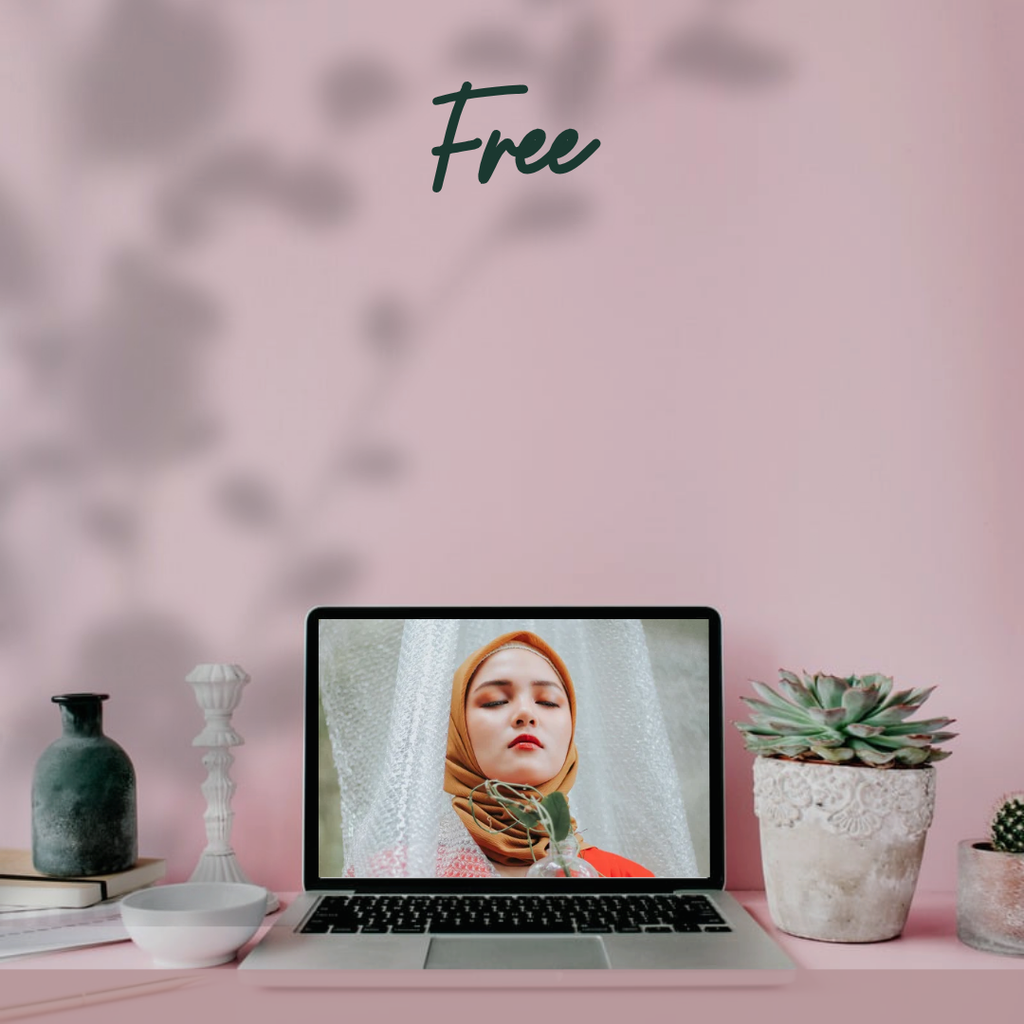

[preview] mask


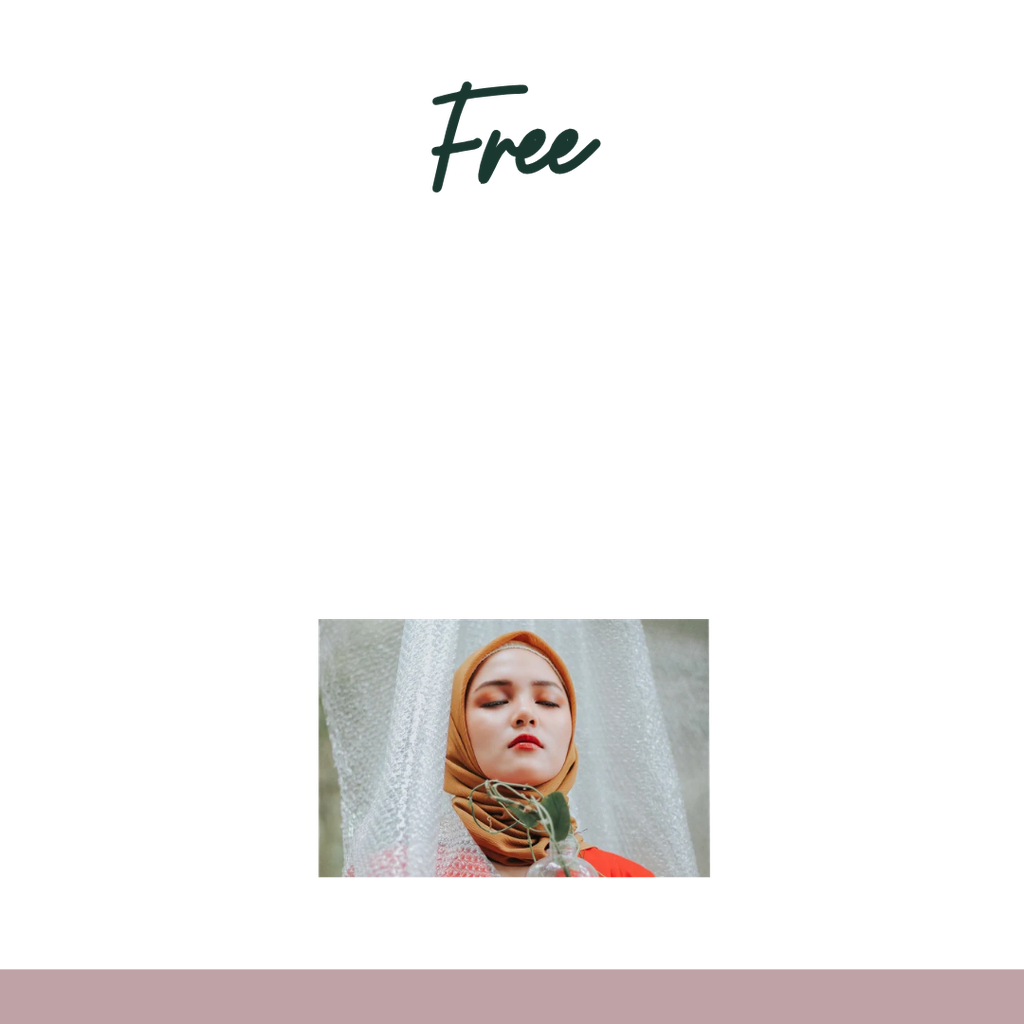

[preview] target (ground truth)


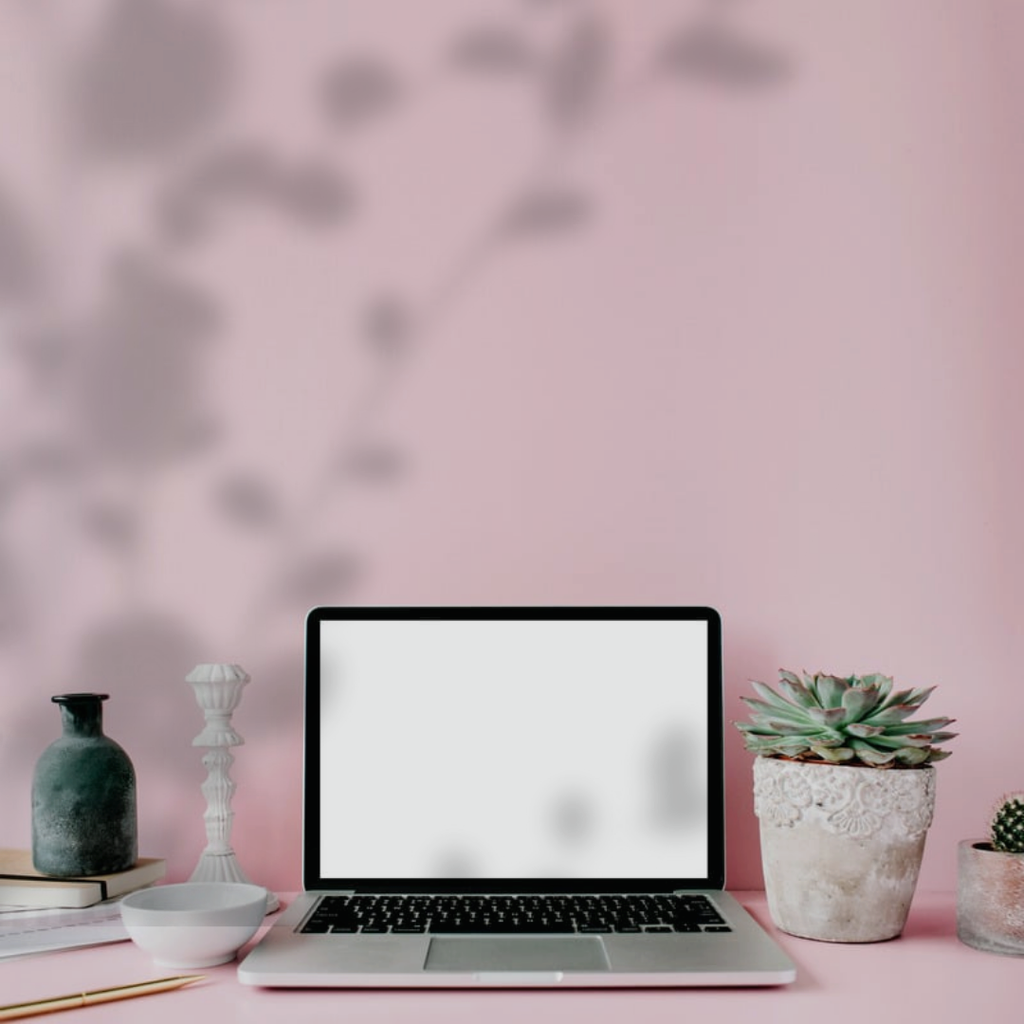

[preview] prediction


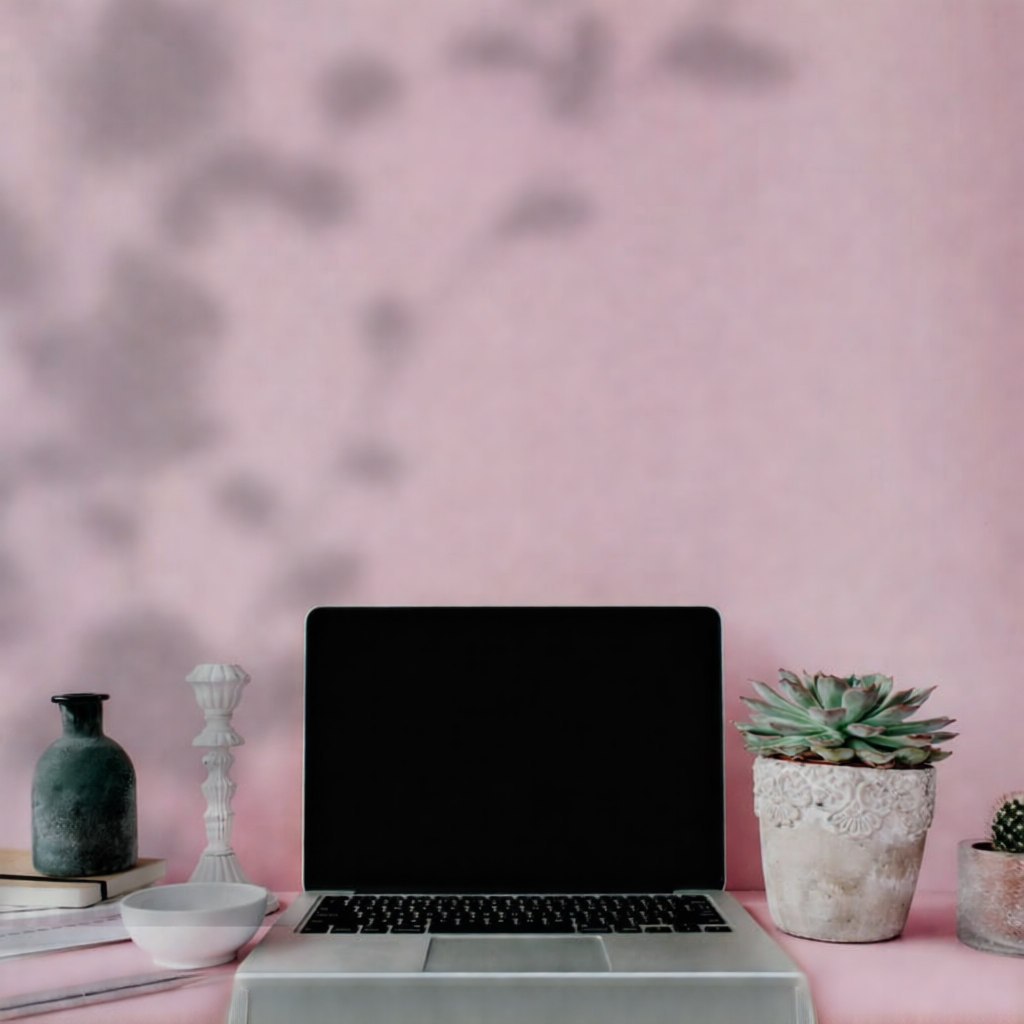

In [3]:
def _resize_to(image: Image.Image, size: tuple[int, int]) -> Image.Image:
    if image.size == size:
        return image
    return image.resize(size, Image.LANCZOS)


src_rgba = Image.open(INPUT_IMAGE_PATH).convert("RGBA")
mask_rgba = Image.open(MASK_IMAGE_PATH).convert("RGBA")
target_rgba = Image.open(TARGET_IMAGE_PATH).convert("RGBA") if TARGET_IMAGE_PATH.exists() else None

width, height = src_rgba.size
pred_rgba = pipe(
    PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    cfg_scale=CFG_SCALE,
    edit_image=[src_rgba, mask_rgba],
    seed=SEED,
    num_inference_steps=NUM_INFERENCE_STEPS,
    height=height,
    width=width,
    edit_image_auto_resize=EDIT_IMAGE_AUTO_RESIZE,
    zero_cond_t=ZERO_COND_T,
).convert("RGBA")

src_rgba = _resize_to(src_rgba, pred_rgba.size)
mask_rgba = _resize_to(mask_rgba, pred_rgba.size)
if target_rgba is not None:
    target_rgba = _resize_to(target_rgba, pred_rgba.size)

w, h = pred_rgba.size
panel = Image.new("RGBA", (w * 4, h), (0, 0, 0, 255))
panel.paste(src_rgba, (0, 0))
panel.paste(mask_rgba, (w, 0))
panel.paste(pred_rgba, (w * 2, 0))
if target_rgba is not None:
    panel.paste(target_rgba, (w * 3, 0))

output_dir = Path("/home/ubuntu/DiffSynth-Studio/output/qwen_object_eraser_inference")
output_dir.mkdir(parents=True, exist_ok=True)
pred_path = output_dir / f"{sample_stem}_pred_{TRAINED_CHECKPOINT_PATH.stem}.png"
panel_path = output_dir / f"{sample_stem}_panel_{TRAINED_CHECKPOINT_PATH.stem}.png"
pred_rgba.save(pred_path)
panel.save(panel_path)

print(f"[saved] pred: {pred_path}")
print(f"[saved] panel: {panel_path}")
print("[preview] input")
display(src_rgba)
print("[preview] mask")
display(mask_rgba)
if target_rgba is not None:
    print("[preview] target (ground truth)")
    display(target_rgba)
print("[preview] prediction")
display(pred_rgba)